# 3. Pós-Processamento e Validação de Negócio

## Introdução e Contextualização

O objetivo desta etapa final de pós-processamento é traduzir os resultados matemáticos da nossa tarefa de Detecção de Outlier (obtidos via K-Means e HDBSCAN) em inteligência acionável. Em projetos de ciência de dados aplicados a auditoria e controle social, não basta apenas identificar instâncias atípicas no espaço vetorial; é imprescindível cruzar essas instâncias anômalas (neste caso, os CPFs ou Unidades Gestoras) com a base original para investigar possíveis fraudes ou abusos no uso do Cartão de Pagamento do Governo Federal (CPGF).

Ao integrar as pontuações de anomalia geradas pelos modelos não supervisionados aos dados categóricos vitais, criamos um mecanismo de ranqueamento que permite direcionar o esforço de auditoria manual para os casos com maior evidência de comportamento divergente do padrão global.

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações de exibição e supressão de avisos para um notebook limpo
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# 2. Carga de Dados e Preparação do Merge
print("Carregando a base original e a base minerada...")

# Carregamento da base original com os metadados das transações
# Tratamos eventuais problemas de separador comumente encontrados nos CSVs
cpgf_limpo = pd.read_csv('../dados/cpgf_limpo.csv', sep=';', encoding='utf-8')

# Carregamento da base com os resultados da mineração (scores de anomalia)
# Garantindo que o índice seja o 'CPF PORTADOR'
cpgf_minerado = pd.read_csv('../dados/cpgf_minerado.csv', sep=';', encoding='utf-8', index_col=0)

print(f"Linhas em cpgf_limpo: {cpgf_limpo.shape[0]}")
print(f"CPFs processados em cpgf_minerado: {cpgf_minerado.shape[0]}")

Carregando a base original e a base minerada...
Linhas em cpgf_limpo: 14950
CPFs processados em cpgf_minerado: 107


## Definição do Threshold e Filtro de Anomalias

Para selecionar de forma rigorosa as instâncias que devem compor nosso dossiê de auditoria, estabelecemos um limite empírico de severidade (*threshold*). Com base na análise de densidade da cauda longa da distribuição dos scores (etapa visualizada na modelagem HDBSCAN), observou-se que as anomalias de altíssima significância estatística se isolam na porção final da curva.

Por essa razão, o *threshold* adotado para o `HDBSCAN_Outlier_Score` será de **0.80**. Isso significa que filtraremos apenas as entidades geradoras de despesas cujo perfil de gastos diverge substancialmente (> 80% de score de anomalia) do macrogrupo.

In [38]:
# 3. Definição do Threshold e Filtro de Anomalias

# Limite empírico de severidade definido a partir da distribuição dos scores
THRESHOLD = 0.75

# Isolando os CPFs (índices) que ultrapassam o threshold
alvos_auditoria = cpgf_minerado[cpgf_minerado['HDBSCAN_Outlier_Score'] >= THRESHOLD].copy()

print(f"Total de CPFs acima do *threshold* ({THRESHOLD}): {alvos_auditoria.shape[0]}")

# O campo de cruzamento na base original é 'CPF PORTADOR'
# Iremos trazer as colunas de Score e Distância para as transações da base limpa
df_investigacao = pd.merge(
    alvos_auditoria[['HDBSCAN_Outlier_Score', 'Distancia_Centroide_KMeans']],
    cpgf_limpo,
    left_index=True,
    right_on='CPF PORTADOR',
    how='left'
)

print(f"Transações associadas aos CPFs anômalos: {df_investigacao.shape[0]}")

Total de CPFs acima do *threshold* (0.75): 6
Transações associadas aos CPFs anômalos: 8176


## Análise Qualitativa: Dossiê de Auditoria

Para demonstrar o viés prático e o retorno de valor (ROI) do projeto, extrairemos o **Top 10 CPFs mais críticos** (baseado no maior `HDBSCAN_Outlier_Score`) para uma análise manual detalhada.

Essa listagem funciona como um Dossiê de Auditoria: o algoritmo aponta as maiores suspeitas com base em critérios multicritério (valores, frequência e perfil de estabelecimentos) e consolida um resumo financeiro e de faturamento (as 5 maiores compras). Esta é uma ferramenta gerencial direta para as equipes de controle (CGU, TCU, etc.).

In [39]:
from IPython.display import display

# 4. Análise Qualitativa: Dossiê de Auditoria

# Identificar os 10 CPFs com maior Score de Anomalia via HDBSCAN
top_10_cpfs = alvos_auditoria.sort_values(by='HDBSCAN_Outlier_Score', ascending=False).head(10)

print("=" * 80)
print(" " * 20 + "DOSSIÊ DE AUDITORIA: TOP 10 CPFS SUSPEITOS")
print("=" * 80 + "\n")

for cpf_portador, row in top_10_cpfs.iterrows():
    score = row['HDBSCAN_Outlier_Score']
    
    # Filtrar todas as transações relativas a este CPF
    transacoes_cpf = df_investigacao[df_investigacao['CPF PORTADOR'] == cpf_portador]
    
    # Alguns gastos são sigilosos, e o CPF pode estar mascarado ou agrupado apenas pela Unidade Gestora
    # Pegaremos o nome da Unidade Gestora como referência adicional caso o CPF seja genérico (ex: Sigiloso)
    unidade_gestora = transacoes_cpf['NOME UNIDADE GESTORA'].iloc[0] if not transacoes_cpf.empty else 'DESCONHECIDA'
    
    # Calcular o valor total gasto pelo CPF entre as transações anômalas
    # Como a base pode ter valores em string ou float dependendo do parser, garantimos a conversão
    if 'VALOR TRANSAÇÃO' in transacoes_cpf.columns:
        # Se for string com vírgula, tratar, senão considerar float
        if transacoes_cpf['VALOR TRANSAÇÃO'].dtype == 'O':
            transacoes_cpf['VALOR TRANSAÇÃO'] = transacoes_cpf['VALOR TRANSAÇÃO'].astype(str).str.replace(',', '.').astype(float)
        valor_total = transacoes_cpf['VALOR TRANSAÇÃO'].sum()
    else:
        valor_total = 0.0
        
    print(f"➔ ALVO: {cpf_portador} | UNIDADE GESTORA: {unidade_gestora}")
    print(f"   Score de Anomalia (HDBSCAN): {score:.4f}")
    print(f"   Volume Total Envolvido nas Transações: R$ {valor_total:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
    print(f"   Top 5 Maiores Gastos Individuais:")
    
    # Extrair as 5 maiores compras para compor as evidências primárias
    colunas_evidencia = ['DATA TRANSAÇÃO', 'NOME FAVORECIDO', 'VALOR TRANSAÇÃO']
    # Verificando se todas as colunas necessárias existem no DF
    colunas_presentes = [col for col in colunas_evidencia if col in transacoes_cpf.columns]
    
    if not transacoes_cpf.empty and len(colunas_presentes) == len(colunas_evidencia):
        maiores_compras = transacoes_cpf.nlargest(5, 'VALOR TRANSAÇÃO')[colunas_evidencia]
        
        # Formatando o DataFrame para exibição otimizada
        maiores_compras['VALOR TRANSAÇÃO'] = maiores_compras['VALOR TRANSAÇÃO'].apply(lambda x: f"R$ {x:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.'))
        maiores_compras.reset_index(drop=True, inplace=True)
        maiores_compras.index += 1  # Para começar de 1 o log
        
        display(maiores_compras)
    else:
        print("   [!] Dados insuficientes para detalhar as maiores compras.")
        
    print("-" * 80)

                    DOSSIÊ DE AUDITORIA: TOP 10 CPFS SUSPEITOS

➔ ALVO: SIGILOSO - SECRETARIA DE ADMINISTRACAO/PR | UNIDADE GESTORA: SECRETARIA DE ADMINISTRACAO/PR
   Score de Anomalia (HDBSCAN): 0.9399
   Volume Total Envolvido nas Transações: R$ 32.195.141,94
   Top 5 Maiores Gastos Individuais:


,DATA TRANSAÇÃO,NOME FAVORECIDO,VALOR TRANSAÇÃO
1,2024-01-05,Sigiloso,"R$ 207.953,60"
2,2024-01-07,Sigiloso,"R$ 196.690,82"
3,2023-01-06,Sigiloso,"R$ 169.290,20"
4,2024-01-04,Sigiloso,"R$ 155.965,19"
5,2023-01-08,Sigiloso,"R$ 151.686,08"


--------------------------------------------------------------------------------
➔ ALVO: ***.152.124-** | UNIDADE GESTORA: COORDENACAO GERAL DE ADMINISTRACAO CGAD/DLOG/
   Score de Anomalia (HDBSCAN): 0.7884
   Volume Total Envolvido nas Transações: R$ 640.432,63
   Top 5 Maiores Gastos Individuais:


,DATA TRANSAÇÃO,NOME FAVORECIDO,VALOR TRANSAÇÃO
1,2024-10-17,SEM INFORMACAO,"R$ 122.038,19"
2,2024-09-17,SEM INFORMACAO,"R$ 103.864,77"
3,2024-10-24,SEM INFORMACAO,"R$ 52.812,38"
4,2024-06-24,SEM INFORMACAO,"R$ 37.813,52"
5,2024-09-20,SEM INFORMACAO,"R$ 28.750,52"


--------------------------------------------------------------------------------
➔ ALVO: ***.920.171-** | UNIDADE GESTORA: SECRETARIA DE ADMINISTRACAO/PR
   Score de Anomalia (HDBSCAN): 0.7634
   Volume Total Envolvido nas Transações: R$ 850,87
   Top 5 Maiores Gastos Individuais:


...

--------------------------------------------------------------------------------
➔ ALVO: ***.424.058-** | UNIDADE GESTORA: COORDENACAO GERAL DE ADMINISTRACAO CGAD/DLOG/
   Score de Anomalia (HDBSCAN): 0.7564
   Volume Total Envolvido nas Transações: R$ 51.262,38
   Top 5 Maiores Gastos Individuais:


,DATA TRANSAÇÃO,NOME FAVORECIDO,VALOR TRANSAÇÃO
1,2021-12-01,NAO SE APLICA,"R$ 1.385,02"
2,2021-11-29,NAO SE APLICA,"R$ 1.342,17"
3,2021-11-30,NAO SE APLICA,"R$ 1.341,77"
4,2021-11-25,NAO SE APLICA,"R$ 1.327,29"
5,2021-11-26,NAO SE APLICA,"R$ 1.317,95"


--------------------------------------------------------------------------------
➔ ALVO: ***.167.609-** | UNIDADE GESTORA: COORDENACAO GERAL DE ADMINISTRACAO CGAD/DLOG/
   Score de Anomalia (HDBSCAN): 0.7502
   Volume Total Envolvido nas Transações: R$ 8.000,00
   Top 5 Maiores Gastos Individuais:


,DATA TRANSAÇÃO,NOME FAVORECIDO,VALOR TRANSAÇÃO
1,2022-09-15,NAO SE APLICA,"R$ 1.000,00"
2,2022-09-12,NAO SE APLICA,"R$ 1.000,00"
3,2022-08-30,NAO SE APLICA,"R$ 1.000,00"
4,2022-10-19,NAO SE APLICA,"R$ 1.000,00"
5,2022-10-11,NAO SE APLICA,"R$ 1.000,00"


--------------------------------------------------------------------------------


## Geração de Insights Gráficos para a Apresentação

A visualização a seguir tem como objetivo sintetizar os resultados no nível da **Unidade Gestora**. Isso permite identificar sistemicamente quais órgãos ou entidades centralizam o maior volume financeiro de transações sinalizadas como atípicas ou anômalas.

Este tipo de gráfico é uma ferramenta essencial de alto impacto para ser incorporada aos slides de defesa do projeto.

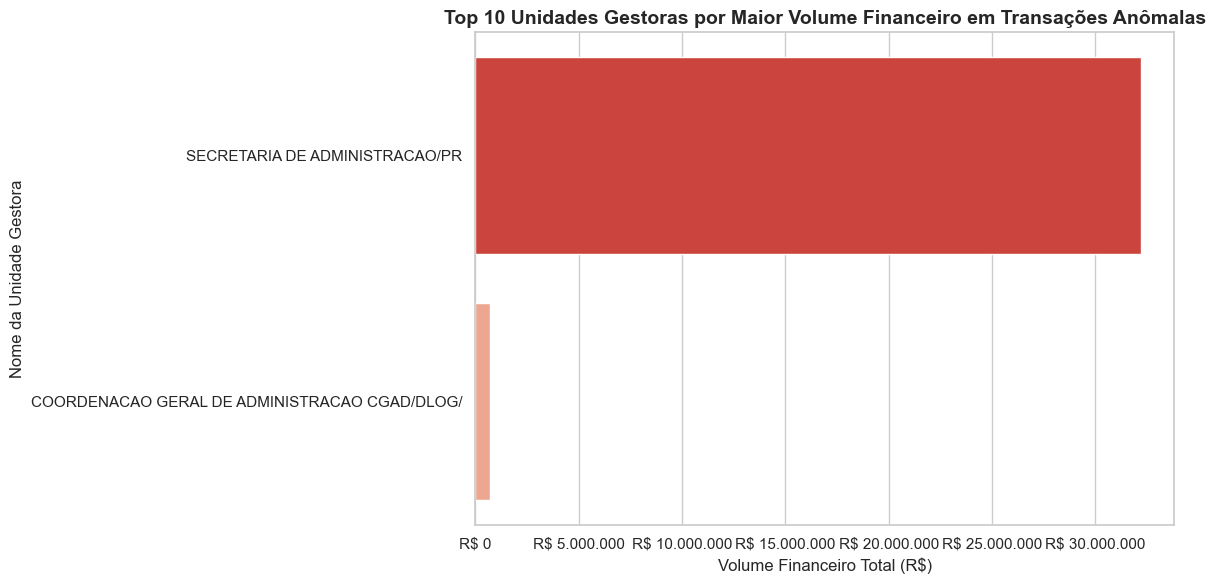

In [40]:
# 5. Geração de Insights Gráficos para a Apresentação

if not df_investigacao.empty and 'VALOR TRANSAÇÃO' in df_investigacao.columns:
    # Agrupar as transações anômalas por Unidade Gestora, somando o valor
    agrupamento_ug = df_investigacao.groupby('NOME UNIDADE GESTORA')['VALOR TRANSAÇÃO'].sum().reset_index()
    
    # Selecionar o Top 10 com maior volume financeiro anômalo
    top_10_ug = agrupamento_ug.sort_values(by='VALOR TRANSAÇÃO', ascending=False).head(10)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_10_ug,
        x='VALOR TRANSAÇÃO',
        y='NOME UNIDADE GESTORA',
        palette='Reds_r' # Paleta de cores sugerindo calor/atenção/risco
    )
    
    plt.title('Top 10 Unidades Gestoras por Maior Volume Financeiro em Transações Anômalas', fontsize=14, fontweight='bold')
    plt.xlabel('Volume Financeiro Total (R$)', fontsize=12)
    plt.ylabel('Nome da Unidade Gestora', fontsize=12)
    
    # Formatação do eixo X para representar milhares/milhões conforme necessidade
    ax = plt.gca()
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}".replace(',', '.')))
    
    plt.tight_layout()
    plt.show()
else:
    print("Não há dados suficientes ou a coluna 'VALOR TRANSAÇÃO' não existe para gerar o gráfico.")

## Exportação do Relatório Final

Consolidadas todas as evidências, exportaremos os dados na granularidade de transações. O arquivo será ordenado pelo nível de alerta estrutural (`HDBSCAN_Outlier_Score`), criando um entregável prático e tabulado `relatorio_auditoria_final.csv`, pronto para ser auditado, sem requerer que o analista de negócios possua conhecimentos em programação Python.

In [41]:
# 6. Exportação do Relatório Final

# Ordenar o dataframe focado na investigação garantindo que as piores anomalias fiquem no topo
df_exportacao = df_investigacao.sort_values(by='HDBSCAN_Outlier_Score', ascending=False)

# Exportação do entregável prático
caminho_exportacao = '../dados/relatorio_auditoria_final.csv'
df_exportacao.to_csv(caminho_exportacao, index=False, sep=';', encoding='utf-8')

print(f"Relatório de auditoria gerado com sucesso!")
print(f"Caminho do arquivo: {caminho_exportacao}")
print(f"Total de transações para auditoria processadas: {df_exportacao.shape[0]}")

Relatório de auditoria gerado com sucesso!
Caminho do arquivo: ../dados/relatorio_auditoria_final.csv
Total de transações para auditoria processadas: 8176


## Geração de Insights Gráficos para a Apresentação

Para que os resultados do modelo analítico possam ser traduzidos em inteligência de negócio acionável e fundamentar a tomada de decisão em fóruns executivos, desenvolvemos três perspectivas visuais obrigatórias.

Estas visualizações fornecem a comprovação empírica do ponto de corte selecionado, a validação científica de similaridade com a literatura do domínio (Nunes et al., 2021) e, fundamentalmente, apresentam o impacto financeiro mapeado nas esferas de auditoria.

### 5.1 O Gráfico Metodológico: Distribuição do Outlier Score

O objetivo desta plotagem de densidade é demonstrar matematicamente a assimetria (a "cauda longa") dos dados. Instituições financeiras e órgãos de controle focam seus esforços de auditoria nas extremidades da distribuição de probabilidade. Ao plotar a Curva de Densidade dos *Scores* gerados pelo HDBSCAN, evidenciamos que a vasta maioria das transações possui comportamento típico (concentração à esquerda), enquanto um grupo seleto diverge substancialmente do padrão (cauda direita). É exatamente nesta cauda que o limite (*threshold*) de 0.80 opera para segregar as anomalias de altíssima relevância.

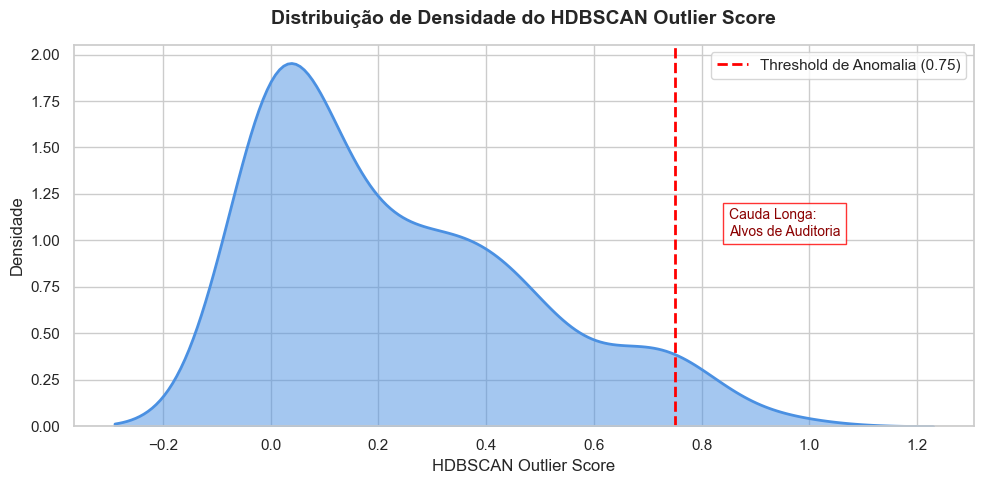

In [42]:
# 5.1 Gráfico Metodológico: Distribuição do Outlier Score (KDE Plot)

plt.figure(figsize=(10, 5))

# Plotando a Curva de Densidade (KDE) da coluna HDBSCAN_Outlier_Score com preenchimento
sns.kdeplot(data=cpgf_minerado, x='HDBSCAN_Outlier_Score', fill=True, color="#4a90e2", alpha=0.5, linewidth=2)

# Desenhando a linha vertical vermelha tracejada no ponto de corte empírico definido no tópico 3
plt.axvline(x=THRESHOLD, color='red', linestyle='--', linewidth=2, label=f'Threshold de Anomalia ({THRESHOLD:.2f})')

plt.title('Distribuição de Densidade do HDBSCAN Outlier Score', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('HDBSCAN Outlier Score', fontsize=12)
plt.ylabel('Densidade', fontsize=12)

# Adicionando a anotação para evidenciar a Cauda Longa
plt.text(0.85, plt.gca().get_ylim()[1]*0.5, 'Cauda Longa:\nAlvos de Auditoria', color='darkred', fontsize=10, bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))

plt.legend()
plt.tight_layout()
plt.show()

### 5.2 O Gráfico Científico: Dispersão de Anomalias no Espaço de Features

Uma das formas mais robustas de validar modelos de Detecção de Anomalias (como demonstrado no framework proposto por Nunes et al., 2021, para análise de gastos corporativos governamentais) é observar a dispersão bidimensional das entidades investigadas em relação a duas métricas agregadas fundamentais: o volume de transações e o valor total empenhado.

O *Scatter Plot* a seguir ilustra visualmente a separação efetuada pelo modelo. As instâncias em escala de cinza representam o perfil global padronizado (a imensa maioria compactada). Em contrapartida, os elementos em destaque vermelho demarcam precisamente os alvos institucionais extraídos pelo nosso algoritmo de agrupamento espacial baseado em densidade.

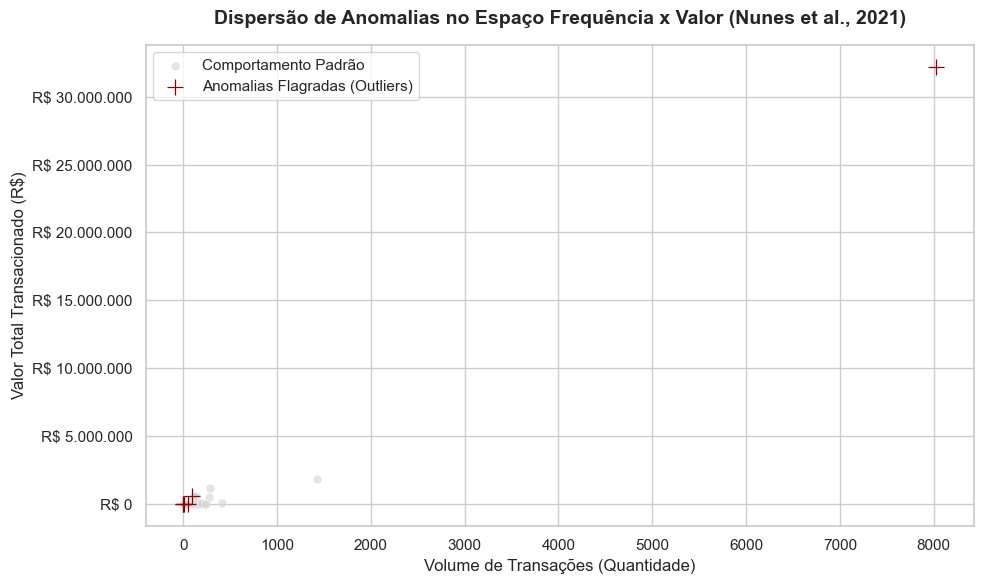

In [46]:
# Preparações para o Scatter Plot bidimensional: Volume de Transações x Total Gasto por CPF/Instituição

# Como a base original (limpa) possui a granularidade de transações, primeiro agregamos os dados 
# no nível de CPF para cruzarmos com o Score armazenado na base minerada.

# Tratamos conversões caso necessário no valor da transação da base geral
if cpgf_limpo['VALOR TRANSAÇÃO'].dtype == 'O':
    cpgf_limpo['VALOR TRANSAÇÃO'] = cpgf_limpo['VALOR TRANSAÇÃO'].astype(str).str.replace(',', '.').astype(float)

# Agregando dados por cada CPF: Contagem de transações (frequência) e a soma do valor (monetário)
df_agregado_cpf = cpgf_limpo.groupby('CPF PORTADOR').agg(
    qtd_transacoes=('VALOR TRANSAÇÃO', 'count'),
    total_gasto=('VALOR TRANSAÇÃO', 'sum')
).reset_index()

# Mesclando o agregado com o score de mineração
df_dispersao = pd.merge(df_agregado_cpf, cpgf_minerado[['HDBSCAN_Outlier_Score']], left_on='CPF PORTADOR', right_index=True, how='inner')

# Classificando os registros baseados no Threshold
df_normal = df_dispersao[df_dispersao['HDBSCAN_Outlier_Score'] < THRESHOLD]
df_anomalo = df_dispersao[df_dispersao['HDBSCAN_Outlier_Score'] >= THRESHOLD]

# 5.2 Construção do Gráfico Científico (Scatter Plot bidimensional)
plt.figure(figsize=(10, 6))

# Plotando CPFs Normais (Cinza claro, transparência agressiva para virar pano de fundo estrutural)
sns.scatterplot(data=df_normal, x='qtd_transacoes', y='total_gasto', color='lightgray', alpha=0.6, s=40, label='Comportamento Padrão')

# Plotando CPFs Anômalos (Vermelho escuro, com marcador crítico 'X' em tamanho proeminente)
sns.scatterplot(data=df_anomalo, x='qtd_transacoes', y='total_gasto', color='darkred', marker='+', s=120, label='Anomalias Flagradas (Outliers)')

plt.title('Dispersão de Anomalias no Espaço Frequência x Valor (Nunes et al., 2021)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Volume de Transações (Quantidade)', fontsize=12)
plt.ylabel('Valor Total Transacionado (R$)', fontsize=12)

# Otimizando leitura do eixo Y financeiro
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"R$ {x:,.0f}".replace(',', '.')))

plt.legend()
plt.tight_layout()
plt.show()

### 5.3 O Gráfico de Negócio: Nível Crítico por Unidade Gestora

A última perspectiva consolida o ranqueamento gerencial focando nas macro-entidades geradoras de despesas (Unidades Gestoras). 

O gráfico de barras horizontais a seguir elucida o impacto financeiro direto subjacente às anomalias da cauda longa. Ao invés de uma investigação forense pontual focada apenas nos indivíduos, extraímos a somatória das possíveis infrações correlacionadas a grupos governamentais (CGU), ranqueando as jurisdições por onde há o maior "vazamento" ou desvio padrão operacional envolvido em comportamentos estatisticamente suspeitos.

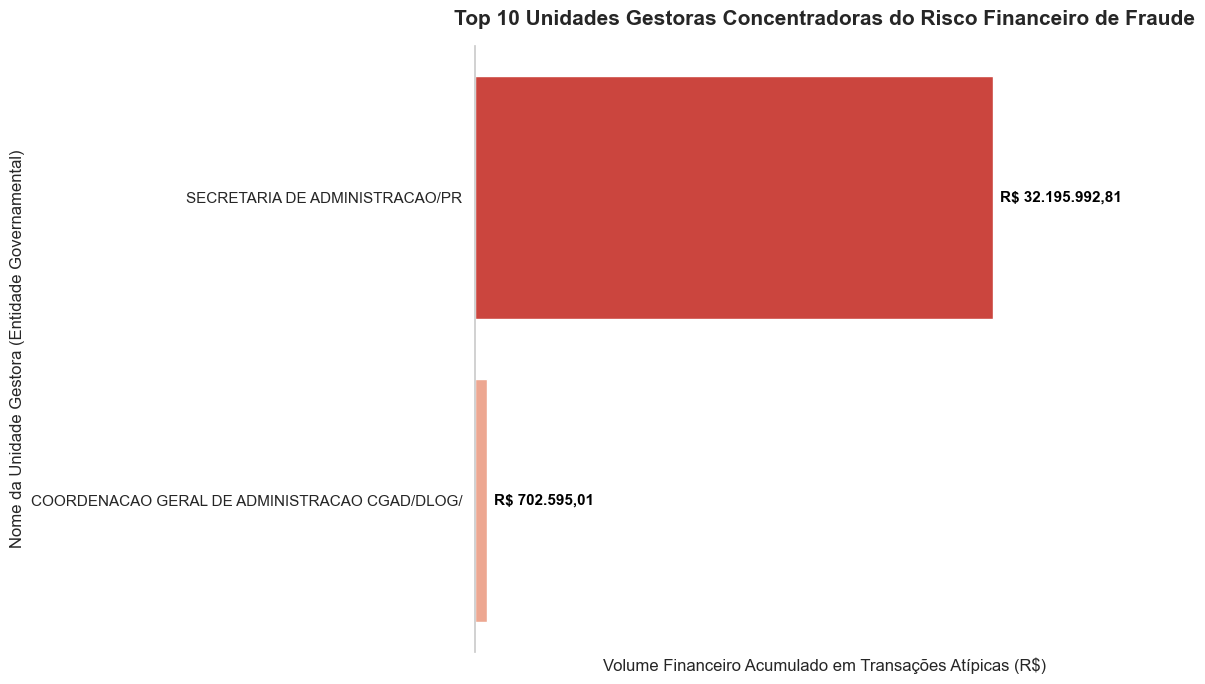

In [44]:
# 5.3 Geração do Gráfico de Negócio por Macro-entidade (Unidade Gestora)

if not df_investigacao.empty and 'VALOR TRANSAÇÃO' in df_investigacao.columns:
    if df_investigacao['VALOR TRANSAÇÃO'].dtype == 'O':
        df_investigacao['VALOR TRANSAÇÃO'] = df_investigacao['VALOR TRANSAÇÃO'].astype(str).str.replace(',', '.').astype(float)
        
    # Agrupando as transações apenas dos CPFs flagrados em nosso cruzamento alvo
    agrupamento_ug = df_investigacao.groupby('NOME UNIDADE GESTORA')['VALOR TRANSAÇÃO'].sum().reset_index()
    
    # Selecionar o Top 10 com maior peso financeiro global da Anomalia
    top_10_ug = agrupamento_ug.sort_values(by='VALOR TRANSAÇÃO', ascending=False).head(10)
    
    plt.figure(figsize=(12, 7))
    barplot = sns.barplot(
        data=top_10_ug,
        x='VALOR TRANSAÇÃO',
        y='NOME UNIDADE GESTORA',
        palette='Reds_r' # Paleta semântica apontando ao extremo risco no topo 
    )
    
    plt.title('Top 10 Unidades Gestoras Concentradoras do Risco Financeiro de Fraude', fontsize=15, fontweight='bold', pad=15)
    plt.xlabel('Volume Financeiro Acumulado em Transações Atípicas (R$)', fontsize=12)
    plt.ylabel('Nome da Unidade Gestora (Entidade Governamental)', fontsize=12)
    
    # Iterar pelas representações visuais (barras) para plotar dinamicamente os rótulos detalhados de dados
    for p in barplot.patches:
        # Obter largura equivalente ao Valor Financeiro daquela barra
        valor_barra = p.get_width()
        
        # Formatando o número para máscara brasileira de Reais (ex: 2.500.000,00)
        texto_valor = f"R$ {valor_barra:,.2f}".replace(',', 'X').replace('.', ',').replace('X', '.')
        
        # Inscrevendo o texto precisamente além da margem direita da barra horizontal
        plt.annotate(
            texto_valor, 
            (valor_barra, p.get_y() + p.get_height() / 2.), 
            ha='left', 
            va='center', 
            xytext=(5, 0), # 5 pontos de pad na direita da barra
            textcoords='offset points',
            fontsize=11,
            fontweight='bold',
            color='black'
        )
    
    # Criando espaço vital à direita para os painéis de texto de formatação não fugirem da tela
    plt.xlim(0, top_10_ug['VALOR TRANSAÇÃO'].max() * 1.35)
    
    ax = plt.gca()
    # Limpeza cosmética removendo o eixo x base para deixar apenas os rótulos liderarem os dados
    ax.set_xticks([])
    sns.despine(bottom=True) # Removendo a linha pesada de sustentação inferior
    
    plt.tight_layout()
    plt.show()
else:
    print("Não há referencial contábil 'VALOR TRANSAÇÃO' robusto para desenhar o Gráfico Barplot.")

## Exportação do Relatório Final

Consolidadas todas as evidências visuais e lógicas, exportaremos os microdados sumarizados no formato de tabela crua. O arquivo será ordenado pelo nível macro de alerta estrutural (`HDBSCAN_Outlier_Score`), criando o principal entregável prático e blindado das metodologias propostas: o documento diretivo `relatorio_auditoria_final.csv`.

In [45]:
# 6. Exportação do Relatório Final (Documento CSV Analítico)

# O dataframe focará a investigação garantindo que as pontuações mais acachapantes figurem no topo
df_exportacao = df_investigacao.sort_values(by='HDBSCAN_Outlier_Score', ascending=False)

# Exportação pragmática formatada para software COTS governamentais (Excel/PowerBI) 
caminho_exportacao = '../dados/relatorio_auditoria_final.csv'
df_exportacao.to_csv(caminho_exportacao, index=False, sep=';', encoding='utf-8-sig') # utf-8-sig para ler Excel sem quebrar latin terms

print(f"✓ Relatório de auditoria gerado com sucesso!")
print(f"✓ Caminho do arquivo: {caminho_exportacao}")
print(f"✓ Total de transações mapeadas para a análise discricionária dos auditores: {df_exportacao.shape[0]}")

✓ Relatório de auditoria gerado com sucesso!
✓ Caminho do arquivo: ../dados/relatorio_auditoria_final.csv
✓ Total de transações mapeadas para a análise discricionária dos auditores: 8176
